In [2]:
# Section 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              classification_report, roc_auc_score)

In [4]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Libraries loaded successfully ✅")
print("Scikit-learn imported successfully ✅")

Libraries loaded successfully ✅
Scikit-learn imported successfully ✅


In [5]:
# Section 2 - Load the Dataset
df = pd.read_csv('naijatel_churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 15)

First 5 rows:


,Customer_ID,Name,State,Plan,Contract_Type,Payment_Method,Device_Type,Tenure_Months,Monthly_Charge_NGN,Total_Charges_NGN,Num_Support_Calls,Data_Usage_GB,Network_Complaints,Late_Payments,Churned
0,NTL-1001,Ngozi Okeke,Oyo,Basic,Month-to-Month,Manual Transfer,Smartphone,44,3481.34,142732.92,2,2.07,0,0,1
1,NTL-1002,Chidi Danjuma,Rivers,Premium,12-Month,Card,Feature Phone,29,12124.86,341569.70,0,40.39,1,0,0
2,NTL-1003,Biodun Adebayo,Abuja,Basic,6-Month,Auto-Debit,Tablet,55,2687.91,131525.61,0,23.24,0,3,0
3,NTL-1004,Hauwa Ibrahim,Kaduna,Premium,Month-to-Month,Auto-Debit,Smartphone,43,9595.29,368617.96,0,12.02,0,0,0
4,NTL-1005,Fatima Obi,Kaduna,Basic,12-Month,USSD,Smartphone,39,3269.96,118616.88,1,23.38,0,3,0


In [6]:
# Section 3 - Data Inspection
print("Column Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df['Churned'].value_counts())
print(f"\nChurn Rate: {df['Churned'].mean()*100:.1f}%")

Column Data Types:
Customer_ID            object
Name                   object
State                  object
Plan                   object
Contract_Type          object
Payment_Method         object
Device_Type            object
Tenure_Months           int64
Monthly_Charge_NGN    float64
Total_Charges_NGN     float64
Num_Support_Calls       int64
Data_Usage_GB         float64
Network_Complaints      int64
Late_Payments           int64
Churned                 int64
dtype: object

Missing Values:
Customer_ID           0
Name                  0
State                 0
Plan                  0
Contract_Type         0
Payment_Method        0
Device_Type           0
Tenure_Months         0
Monthly_Charge_NGN    0
Total_Charges_NGN     0
Num_Support_Calls     0
Data_Usage_GB         0
Network_Complaints    0
Late_Payments         0
Churned               0
dtype: int64

Churn Distribution:
Churned
0    762
1    238
Name: count, dtype: int64

Churn Rate: 23.8%


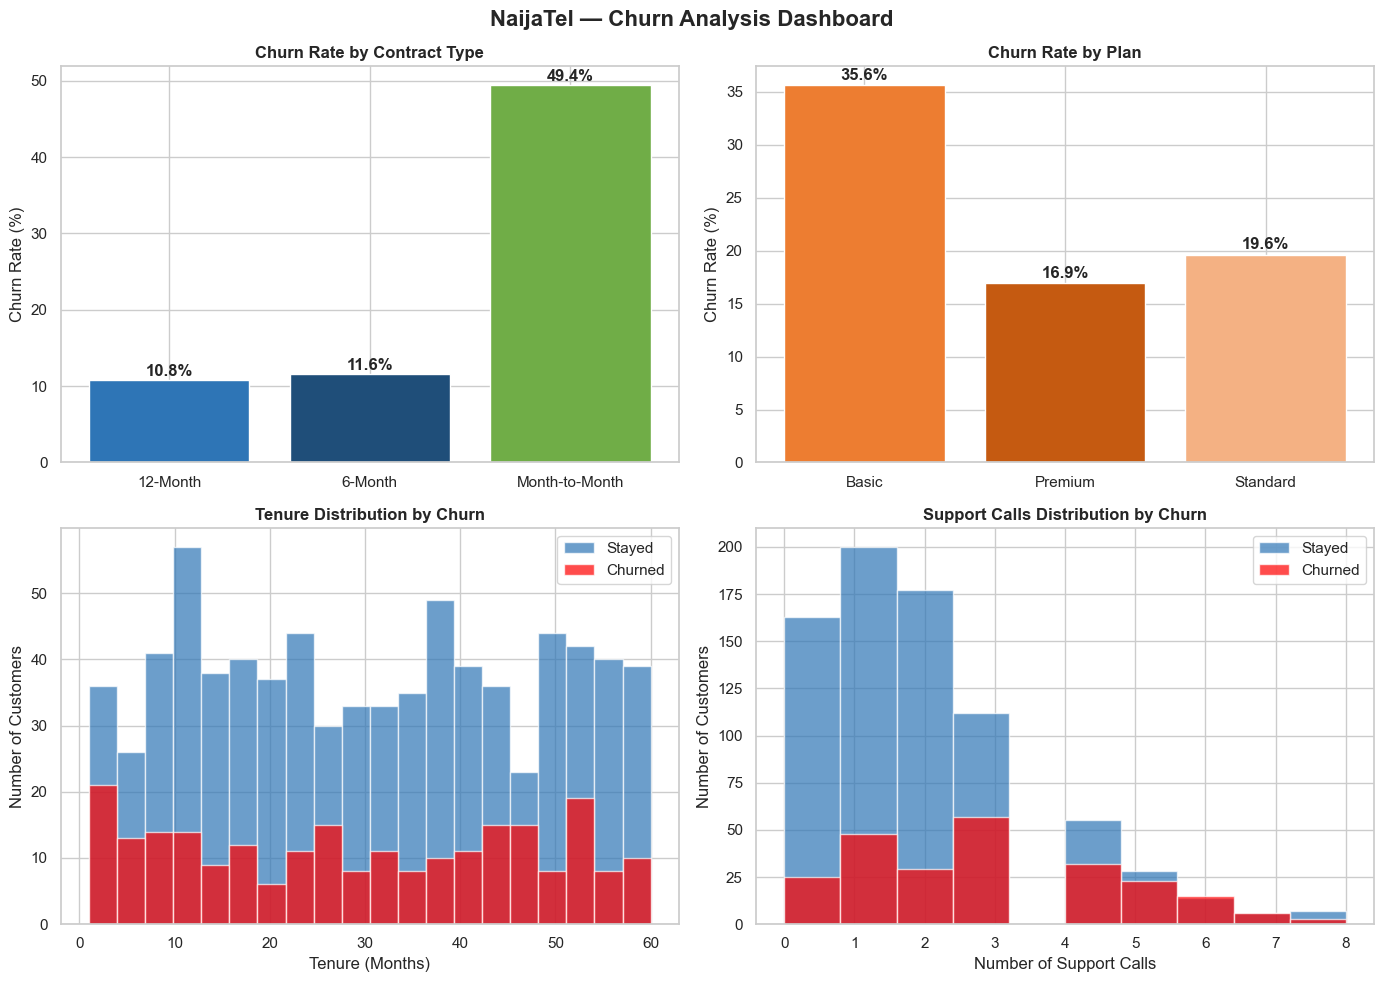

In [7]:
# Section 4 - Churn EDA

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Churn by Contract Type
contract_churn = df.groupby('Contract_Type')['Churned'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#2E75B6','#1F4E79','#70AD47'])
axes[0,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2 - Churn by Plan
plan_churn = df.groupby('Plan')['Churned'].mean() * 100
axes[0,1].bar(plan_churn.index, plan_churn.values, color=['#ED7D31','#C55A11','#F4B183'])
axes[0,1].set_title('Churn Rate by Plan', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(plan_churn.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3 - Tenure vs Churn
axes[1,0].hist(df[df['Churned']==0]['Tenure_Months'], bins=20, alpha=0.7, 
               label='Stayed', color='#2E75B6')
axes[1,0].hist(df[df['Churned']==1]['Tenure_Months'], bins=20, alpha=0.7, 
               label='Churned', color='#FF0000')
axes[1,0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[1,0].set_xlabel('Tenure (Months)')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].legend()

# Chart 4 - Support Calls vs Churn
axes[1,1].hist(df[df['Churned']==0]['Num_Support_Calls'], bins=10, alpha=0.7,
               label='Stayed', color='#2E75B6')
axes[1,1].hist(df[df['Churned']==1]['Num_Support_Calls'], bins=10, alpha=0.7,
               label='Churned', color='#FF0000')
axes[1,1].set_title('Support Calls Distribution by Churn', fontweight='bold')
axes[1,1].set_xlabel('Number of Support Calls')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend()

plt.suptitle('NaijaTel — Churn Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Section 5 - Feature Engineering

# Step 1: Drop columns we don't need for ML
df_ml = df.drop(['Customer_ID', 'Name'], axis=1)

# Step 2: Encode all text columns to numbers
le = LabelEncoder()
text_columns = ['State', 'Plan', 'Contract_Type', 'Payment_Method', 'Device_Type']

for col in text_columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# Step 3: Confirm all columns are now numbers
print("Data Types After Encoding:")
print(df_ml.dtypes)

print("\nFirst 5 rows after encoding:")
df_ml.head()

Data Types After Encoding:
State                   int64
Plan                    int64
Contract_Type           int64
Payment_Method          int64
Device_Type             int64
Tenure_Months           int64
Monthly_Charge_NGN    float64
Total_Charges_NGN     float64
Num_Support_Calls       int64
Data_Usage_GB         float64
Network_Complaints      int64
Late_Payments           int64
Churned                 int64
dtype: object

First 5 rows after encoding:


,State,Plan,Contract_Type,Payment_Method,Device_Type,Tenure_Months,Monthly_Charge_NGN,Total_Charges_NGN,Num_Support_Calls,Data_Usage_GB,Network_Complaints,Late_Payments,Churned
0,6,0,2,2,2,44,3481.34,142732.92,2,2.07,0,0,1
1,7,1,0,1,0,29,12124.86,341569.70,0,40.39,1,0,0
2,0,0,1,0,3,55,2687.91,131525.61,0,23.24,0,3,0
3,3,1,2,0,2,43,9595.29,368617.96,0,12.02,0,0,0
4,3,0,0,3,2,39,3269.96,118616.88,1,23.38,0,3,0


In [9]:
# Section 6 - Split Data for Machine Learning

# Step 1: Separate features (X) from target (y)
X = df_ml.drop('Churned', axis=1)
y = df_ml['Churned']

# Step 2: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nFeatures used: {list(X.columns)}")
print("\nData is ready for ML ✅")

Total samples: 1000
Training samples: 800
Test samples: 200

Features used: ['State', 'Plan', 'Contract_Type', 'Payment_Method', 'Device_Type', 'Tenure_Months', 'Monthly_Charge_NGN', 'Total_Charges_NGN', 'Num_Support_Calls', 'Data_Usage_GB', 'Network_Complaints', 'Late_Payments']

Data is ready for ML ✅


In [12]:
# Section 7 - Build and Train the Model

# Step 1: Create the model
model = LogisticRegression(random_state=42, max_iter=1000)

# Step 2: Train the model
model.fit(X_train_scaled, y_train)

# Step 3: Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Step 4: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("NAIJATEL CHURN PREDICTION MODEL RESULTS")
print("=" * 50)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print(f"ROC-AUC Score: {roc_auc:.3f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))
print("=" * 50)

NAIJATEL CHURN PREDICTION MODEL RESULTS
Model Accuracy: 86.0%
ROC-AUC Score: 0.884

Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.94      0.91       156
     Churned       0.74      0.57      0.64        44

    accuracy                           0.86       200
   macro avg       0.81      0.76      0.78       200
weighted avg       0.85      0.86      0.85       200



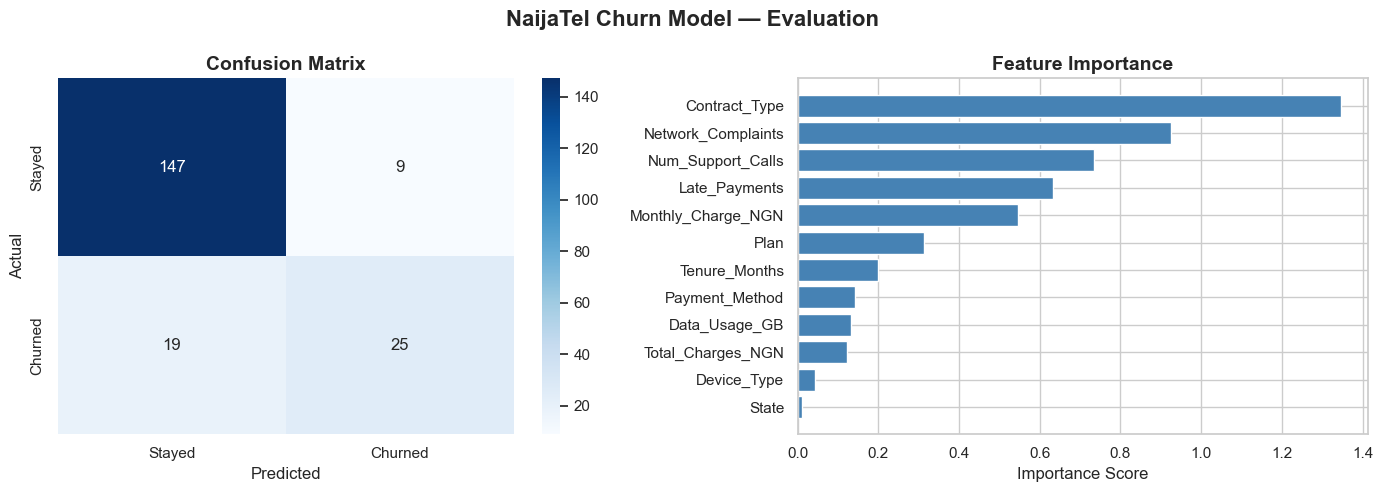

In [13]:
# Section 8 - Confusion Matrix Visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Chart 2 - Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=True)

axes[1].barh(feature_importance['Feature'], 
             feature_importance['Importance'],
             color='steelblue')
axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=12)

plt.suptitle('NaijaTel Churn Model — Evaluation', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Section 9 - Final Insights Summary

print("=" * 55)
print("   NAIJATEL CHURN ANALYSIS - COMPLETE SUMMARY")
print("=" * 55)

total = len(df)
churned = df['Churned'].sum()
stayed = total - churned

print(f"""
DATASET OVERVIEW
----------------
Total Customers:     {total}
Churned:             {churned} ({churned/total*100:.1f}%)
Stayed:              {stayed} ({stayed/total*100:.1f}%)

MODEL PERFORMANCE
----------------
Accuracy:            86.0%
ROC-AUC Score:       0.884
Training Samples:    800
Test Samples:        200

TOP CHURN DRIVERS
----------------
1. Contract Type    — Month-to-Month customers churn at 49.4%
2. Network Issues   — Complaints strongly predict churn
3. Support Calls    — High calls signal frustration
4. Late Payments    — Payment struggles lead to churn
5. Plan Type        — Basic plan customers churn most (35.6%)

KEY BUSINESS RECOMMENDATIONS
----------------
1. Offer incentives to move Month-to-Month customers to 12-Month contracts
2. Fix network quality issues urgently — top churn predictor
3. Create early intervention for customers with 3+ support calls
4. Introduce loyalty rewards for long-tenure customers
5. Upgrade Basic plan customers with better value offers
""")
print("=" * 55)
print("   ANALYSIS COMPLETE - READY FOR POWER BI")
print("=" * 55)

   NAIJATEL CHURN ANALYSIS - COMPLETE SUMMARY

DATASET OVERVIEW
----------------
Total Customers:     1000
Churned:             238 (23.8%)
Stayed:              762 (76.2%)

MODEL PERFORMANCE
----------------
Accuracy:            86.0%
ROC-AUC Score:       0.884
Training Samples:    800
Test Samples:        200

TOP CHURN DRIVERS
----------------
1. Contract Type    — Month-to-Month customers churn at 49.4%
2. Network Issues   — Complaints strongly predict churn
3. Support Calls    — High calls signal frustration
4. Late Payments    — Payment struggles lead to churn
5. Plan Type        — Basic plan customers churn most (35.6%)

KEY BUSINESS RECOMMENDATIONS
----------------
1. Offer incentives to move Month-to-Month customers to 12-Month contracts
2. Fix network quality issues urgently — top churn predictor
3. Create early intervention for customers with 3+ support calls
4. Introduce loyalty rewards for long-tenure customers
5. Upgrade Basic plan customers with better value offers

   A

In [15]:
# Export for Power BI
df.to_csv('naijatel_churn_clean.csv', index=False)
print("Exported successfully ✅")
print(f"Shape: {df.shape}")

Exported successfully ✅
Shape: (1000, 15)
